In [ ]:
 # Import basic libraries
import matplotlib.pyplot as plt
import random
import numpy as np
import torch

# set common seed for all libraries (Same seed as Assignment 3)
random.seed(24)
np.random.seed(24)
torch.manual_seed(24)
torch.cuda.manual_seed_all(24)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# NICE, GAN, and EBM Comparison on MNIST

## Import data

In [ ]:
from torchvision import datasets, transforms

In [ ]:
# import MNIST test dataset
transform = transforms.Compose([transforms.ToTensor()])
dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)


100%|██████████| 9.91M/9.91M [00:00<00:00, 16.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 492kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.60MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.54MB/s]


## Preprocess and Split Data

In [ ]:
# seperate images and labels from dataset and preprocess images
images = []
labels = []

for i in range(len(dataset)):
    image, label = dataset[i]
    # round images to map them into zero and one
    images.append(np.round(image))
    labels.append(label)

images = torch.stack(images).to(torch.float32)
labels = torch.tensor(labels)

In [ ]:
# Collect train and test dataset
X_train = images[:1000]
y_train = labels[:1000]

X_test = images[1000:2000]
y_test = labels[1000:2000]


In [ ]:
# check data type
X_train.dtype, X_test.dtype

(torch.float32, torch.float32)

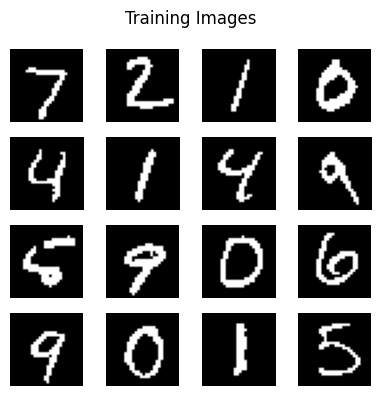

In [ ]:
# show train images
fig, axes = plt.subplots(4,4, figsize=(4,4))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(X_train[i].reshape(28,28), cmap='gray')
    ax.axis('off')

plt.suptitle('Training Images')
plt.tight_layout()
plt.show()


## Data Loader


In [ ]:
from torch.utils.data import DataLoader


In [ ]:
# create a DataLoader for the train set that loads X_train
train_loader = DataLoader(X_train, batch_size=64, shuffle=True)

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

## load pretrained models

In [ ]:
from torch import nn, optim
from sklearn.mixture import GaussianMixture

### GMM
For GMM I re-trained the previous model with same random seed, because I didn't save this model

In [ ]:
# train GMM model with 10 components (dimension of laten variable z)
gmm = GaussianMixture(n_components=10, covariance_type='diag',max_iter=5000, random_state=24)
gmm.fit(X_train.view(-1,784)) # Flaten MNIST to [1000, 784]


GaussianMixture(covariance_type='diag', max_iter=5000, n_components=10,
                random_state=24)

In [ ]:
# Generate 1000 samples using GMM
gmm_samples =  gmm.sample(n_samples=1000)[0]

# Randomly shuffle samples
np.random.shuffle(gmm_samples)

### VAE

In [ ]:
class Encoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.enc = nn.Sequential(
            nn.Linear(784, 400),
            nn.ReLU(),
        )
        self.mu = nn.Linear(400, latent_dim)
        self.log_var = nn.Linear(400, latent_dim)

    def forward(self, x):
        h = self.enc(x)
        return self.mu(h), self.log_var(h)

class Decoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.dec = nn.Sequential(
            nn.Linear(latent_dim, 400),
            nn.ReLU(),
            nn.Linear(400, 784),
            nn.Sigmoid(),
        )

    def forward(self, z):
        return self.dec(z)

class VAE(nn.Module):
    def __init__(self, latent_dim=2):
        super().__init__()
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)

    def reparameterize(self, mu, log_var):

        std = torch.exp(0.5*log_var)
        eps = torch.normal(mean=0,std=1,size=mu.shape).to(std.device)
        return mu+eps*std

    def forward(self, x):
        mu, log_var = self.encoder(x)
        z = self.reparameterize(mu, log_var)
        recon_x = self.decoder(z)
        return recon_x, mu, log_var


In [ ]:
def vae_loss(recon_x, x, mu, log_var):

    # Reconstruction Loss:
    recon_loss=nn.functional.mse_loss(recon_x,x,reduction='sum')

    # KL Divergence Loss:
    kl_loss=-0.5*torch.sum(1 +log_var-mu.pow(2)-log_var.exp())

    # Total loss combines both terms
    loss = recon_loss + kl_loss

    return loss, recon_loss, kl_loss


In [ ]:
# Load saved VAE model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
VAE_model = VAE(latent_dim=2)
if torch.cuda.is_available():
   VAE_model.load_state_dict(torch.load('/content/drive/MyDrive/experiments/mnist_vae/checkpoints/vae_epoch250.pt'))
else:
   VAE_model.load_state_dict(torch.load('/content/drive/MyDrive/experiments/mnist_vae/checkpoints/vae_epoch250.pt',map_location=torch.device('cpu')))
VAE_model.to(device)
VAE_model.eval()

VAE(
  (encoder): Encoder(
    (enc): Sequential(
      (0): Linear(in_features=784, out_features=400, bias=True)
      (1): ReLU()
    )
    (mu): Linear(in_features=400, out_features=2, bias=True)
    (log_var): Linear(in_features=400, out_features=2, bias=True)
  )
  (decoder): Decoder(
    (dec): Sequential(
      (0): Linear(in_features=2, out_features=400, bias=True)
      (1): ReLU()
      (2): Linear(in_features=400, out_features=784, bias=True)
      (3): Sigmoid()
    )
  )
)

### NADE

In [ ]:
# 5. NADE Model
class NADE(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=512):
        """Initialize the Neural Autoregressive Density Estimation model.

        Args:
            input_dim (int): Dimension of input data (flattened image size)
            hidden_dim (int): Number of units in hidden layer
        """
        super().__init__()
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.W = nn.Parameter(torch.randn(input_dim, hidden_dim) * 0.01)
        self.c = nn.Parameter(torch.zeros(hidden_dim))
        self.V = nn.Parameter(torch.randn(hidden_dim, input_dim) * 0.01)
        self.b = nn.Parameter(torch.zeros(input_dim))

        # Training metadata
        self.start_epoch = 0
        self.best_loss = float('inf')
        self.train_history = []
        self.test_history = []

    def forward(self, x):
        """Forward pass through the NADE model.

        Args:
            x (torch.Tensor): Input tensor of shape (batch_size, input_dim)

        Returns:
            tuple: (x_hat, all_h) where:
                x_hat: reconstructed probabilities for each dimension
                all_h: all hidden states during autoregressive process
        """
        batch_size = x.size(0)
        x_hat = torch.zeros_like(x)
        all_h = []
        for d in range(self.input_dim):
            # Compute pre-activation for dimension d:
            a_d = self.c +  torch.matmul(x[:, :d], self.W[:d])
            h_d = torch.sigmoid(a_d)
            # Compute output probability for dimension d:
            p_d = torch.sigmoid(self.b[d] + torch.matmul(h_d, self.V[:, d]))
            x_hat[:, d] = p_d
            all_h.append(h_d)
        return x_hat, torch.stack(all_h, dim=1)

    def log_prob(self, x):
        """Compute log probability of input samples under the model.

        Args:
            x (torch.Tensor): Input tensor of shape (batch_size, input_dim)

        Returns:
            torch.Tensor: Log probabilities for each sample (batch_size)
        """
        x_hat, _ = self.forward(x)
        # Compute Bernoulli log likelihood:
        log_prob = x * torch.log(x_hat + 1e-6) + (1 - x) * torch.log(1 - x_hat + 1e-6)


        # Sum over all dimensions (input_dim)
        return log_prob.sum(dim=1)


    def generate_samples(self, num_samples=10):
        """
        Generates new images via ancestral sampling
        Args:
            num_samples: How many images to generate
        Returns:
            Tensor of shape (num_samples, input_dim)
        """
        samples = torch.zeros(num_samples, 784).to(device)
        with torch.no_grad():
            for d in range(784):
                p_d = self.forward(samples)[0][:, d]
                samples[:, d] = torch.bernoulli(p_d)
        return samples.cpu()

In [ ]:
# Load saved NADE model
path = '/content/drive/MyDrive/experiments/mnist_nade/checkpoints/nade_epoch250.pt'
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
NADE_model = NADE()
if torch.cuda.is_available():
 NADE_model.load_state_dict(torch.load(path))
else:
 NADE_model.load_state_dict(torch.load(path,map_location=torch.device('cpu')))
NADE_model.to(device)
NADE_model.eval()

NADE()

# Task 2: Train a flow-based model (NICE)
<div dir='rtl' align='justify'>

برای این بخش ابتدا از یک مدل با ساختار CNN استفاده کردم. ولی چون با MLP نتیجه بهتری میگرفتم همون ساختار رو نگه داشتم.
</div>


In [ ]:
# needed packages for this task
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import Normal
import os
import time

In [ ]:
# backbone of each f
class AdditiveCoupling(nn.Module):
    def __init__(self, dim, mask):
        super().__init__()

        self.register_buffer("mask", mask)  # shape: (dim,)
        in_dim = int(mask.sum().item())
        out_dim = dim - in_dim
        self.init_size = 7
        self.net = nn.Sequential(
            nn.Linear(in_dim, 256), nn.ReLU(),
            nn.Linear(256, 512), nn.ReLU(),
            nn.Linear(512, 1080), nn.ReLU(),
            nn.Linear(1080, 1080), nn.ReLU(),
            nn.Linear(1080, 512), nn.ReLU(),
            nn.Linear(512, 256), nn.ReLU(),
            nn.Linear(256, out_dim), nn.Tanh()
        )

    def forward(self, x, log_det):
        # split using slicing_index (first d dimension is considered xa, and others considered xb)
        xa = x[:, self.mask.bool()]
        tb = self.net(xa)
        x_out = x.clone()
        x_out[:, ~self.mask.bool()] = x_out[:, ~self.mask.bool()] + tb
        # additive coupling has zero log-det contribution
        return x_out, log_det

    def inverse(self, y, log_det):
        ya = y[:, self.mask.bool()]
        tb = self.net(ya)
        x_out = y.clone()
        x_out[:, ~self.mask.bool()] = x_out[:, ~self.mask.bool()] - tb
        return x_out, log_det


# Global diagonal scaling (the only log-det term in NICE)
class DiagScale(nn.Module):
    def __init__(self, dim):
        super().__init__()

        self.s = nn.Parameter(torch.zeros(dim))

    def forward(self, x, log_det):
        x_out = x * torch.exp(self.s)
        log_det = log_det + self.s.sum().expand(x.shape[0])
        return x_out, log_det

    def inverse(self, y, log_det):
        x_out = y * torch.exp(-self.s)
        log_det = log_det - self.s.sum().expand(y.shape[0])
        return x_out, log_det


# NICE model
class NICE(nn.Module):
    def __init__(self, dim, num_couplings=4):
        super().__init__()
        self.dim = dim
        self.device = 'cuda' if torch.cuda.is_available() else 'cpu'
        # a list of slicing dimensions that determine which half of data is xa in each couplings
        masks = []
        for i in range(num_couplings):
            m = torch.zeros(dim)
            m[i % 2::2] = 1 # alternate which half is "a"
            masks.append(m)

        self.couplings = nn.ModuleList([
            AdditiveCoupling(dim, mask=m) for m in masks
        ])
        self.scale = DiagScale(dim)

        # register base distribution params as buffers
        self.register_buffer("base_loc", torch.zeros(dim))
        self.register_buffer("base_scale", torch.ones(dim))

    # base distribution for latent space (z)
    def _base(self):
        return  Normal(self.base_loc, self.base_scale)


    # z = f(x), returns (z, log_det f)
    def forward(self, x):
        log_det = torch.zeros(x.shape[0], device=x.device)
        h = x
        for c in self.couplings:
            h, log_det = c.forward(h, log_det)
        h, log_det = self.scale.forward(h, log_det)
        return h, log_det

    # x = f^{-1}(z), returns (x, log_det f^{-1}) = (x, -log_det f)
    def inverse(self, z):
        log_det = torch.zeros(z.shape[0], device=z.device)
        h = z
        h, log_det = self.scale.inverse(h, log_det)
        for c in reversed(self.couplings):
            h, log_det = c.inverse(h, log_det)
        return h, log_det

    # log p_X(x) = log p_Z(f(x)) + log|det J_f(x)|
    def log_prob(self, x):
        z, log_det = self.forward(x)
        log_pz = self._base().log_prob(z).sum(dim=1)
        return log_pz + log_det

    # sample by z~N(0,I), x = f^{-1}(z)
    @torch.no_grad()
    def sample(self, n):
        z = self._base().sample((n,)).to(self.device)
        x, _ = self.inverse(z)
        return x


In [ ]:
# Define the NICE model and the optimizer
dim = 784
NICE_model = NICE(dim, num_couplings=16).to(device)
optimizer = torch.optim.Adam(NICE_model.parameters(), lr=1e-3)

In [ ]:
#Base drive path
base_path = "/content/drive/MyDrive/experiments/mnist_NICE"
ckpt_path = os.path.join(base_path, "checkpoints") #path for checkpoints
log_path = os.path.join(base_path, "logs") #Path for useful information (epoch number, training time for each epoch, and loss)

for d in (ckpt_path, log_path):
    os.makedirs(d, exist_ok=True)

log_path = os.path.join(log_path, "training_log.csv")
with open(log_path, "w") as f:
    f.write("epoch,elapsed_time_s,train_loss\n")


In [ ]:
#Training loop
num_epochs = 500

NICE_model.train()

for epoch in range(1, num_epochs + 1):

    start_time = time.time()
    epoch_loss = 0

    for batch in train_loader:
        batch = batch.view(-1, 784).to(device)
        optimizer.zero_grad()
        loss = -NICE_model.log_prob(batch).mean()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss/len(train_loader)
    training_time = time.time()-start_time  #Training time for epoch

    # Save log metrics
    with open(log_path, "a") as f:
        f.write(f"{epoch},{training_time:.2f},{avg_loss:.6f}\n")

    print(f"Epoch {epoch}/{num_epochs}, Loss={avg_loss:.4f}")


print("Training complete.")
# Save checkpoint
torch.save(NICE_model.state_dict(),os.path.join(ckpt_path, f"nice_epoch{epoch:03d}.pt"))

Epoch 1/500, Loss=750.7647
Epoch 2/500, Loss=734.4026
Epoch 3/500, Loss=720.0165
Epoch 4/500, Loss=704.9902
Epoch 5/500, Loss=690.7252
Epoch 6/500, Loss=676.9839
Epoch 7/500, Loss=663.5348
Epoch 8/500, Loss=650.2577
Epoch 9/500, Loss=637.3029
Epoch 10/500, Loss=624.1826
Epoch 11/500, Loss=611.2728
Epoch 12/500, Loss=598.3965
Epoch 13/500, Loss=585.9016
Epoch 14/500, Loss=573.1096
Epoch 15/500, Loss=560.4529
Epoch 16/500, Loss=547.6798
Epoch 17/500, Loss=535.0750
Epoch 18/500, Loss=522.6095
Epoch 19/500, Loss=509.9785
Epoch 20/500, Loss=497.4682
Epoch 21/500, Loss=484.7645
Epoch 22/500, Loss=472.4514
Epoch 23/500, Loss=460.2508
Epoch 24/500, Loss=447.8368
Epoch 25/500, Loss=435.1902
Epoch 26/500, Loss=422.5794
Epoch 27/500, Loss=410.3488
Epoch 28/500, Loss=398.1110
Epoch 29/500, Loss=385.5449
Epoch 30/500, Loss=373.2679
Epoch 31/500, Loss=360.8687
Epoch 32/500, Loss=348.6103
Epoch 33/500, Loss=336.5155
Epoch 34/500, Loss=324.3757
Epoch 35/500, Loss=311.9795
Epoch 36/500, Loss=299.6825
E

# Task 3: Train a GAN model
<div dir='rtl' align='justify'>

ولی برای این بخش ساختار CNN نتیجه بهتری میداد پس از CNN استفاده شد.
</div>

In [ ]:
# needed packages for this task
import torch.nn as nn
import os, time

In [ ]:
# A class for the generator model
class Generator(nn.Module):
    def __init__(self, latent_dim=128, img_shape=(1, 28, 28)):
        super().__init__()

        self.latent_dim = latent_dim
        img_channels = img_shape[0]
        img_size = img_shape[1]
        self.init_size = img_size // 4

        # fully connected layer to project latent vector into feature map
        self.project = nn.Sequential(
            nn.Linear(latent_dim, 256 * self.init_size * self.init_size),
            nn.ReLU()
        )

        # convolutional transpose blocks (upsampling layers)
        self.conv = nn.Sequential(
            # first layer 7x7 to 14x14
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            # second layer 14x14 to 28x28
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            # extra conv layer to refine the image
            nn.Conv2d(64, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            # final output layer
            nn.Conv2d(32, img_channels, kernel_size=3, stride=1, padding=1),
            nn.Tanh()
        )

    def forward(self, z):
        # project and reshape the latent vector
        out = self.project(z)
        out = out.view(z.size(0), 256, self.init_size, self.init_size)
        # pass through conv blocks
        generated_img = self.conv(out)
        return generated_img # generated images

# A class for the discriminator model
class Discriminator(nn.Module):
    def __init__(self, img_shape=(1, 28, 28)):
        super().__init__()

        img_channels = img_shape[0]
        img_size = img_shape[1]

        self.conv_classifier = nn.Sequential(
            # first conv 28x28 to 14x14
            nn.Conv2d(img_channels, 64, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2),

            # second conv 14x14 to 7x7
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),

            # third conv 7x7 to 3x3
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),

            nn.Flatten(),

            # fully connected layer
            nn.Linear(256 * 3 * 3, 1),
        )

    def forward(self, img):
        logit = self.conv_classifier(img)
        return logit # logits


# GAN model (mix of generator and discriminator)
class GAN(nn.Module):

    def __init__(self, img_shape=(1,28,28), latent_dim=128,):
        super().__init__()
        self.latent_dim = latent_dim
        self.G = Generator(latent_dim, img_shape, )
        self.D = Discriminator(img_shape)
        self.device = 'cuda' if torch.cuda.is_available() else 'cpu'

    def sample_noise(self, n):
        return torch.randn(n, self.latent_dim, device=self.device)

    @torch.no_grad()
    def generate(self, n):
        z = self.sample_noise(n)
        imgs = self.G(z)
        return imgs


In [ ]:
# define model, loss, and optimizer
# n_discriminator = 2  # D steps for training the discriminator per 1 step training the generator
# label_smooth = 0.8   # real label smoothing: avoids the discriminator from becoming overconfident and helps the generator train better
gan = GAN().to(device)

criterion = nn.BCEWithLogitsLoss() # this criterion will be used to define the loss for the generator and the discriminator.
optimizer_D = torch.optim.Adam(gan.D.parameters(), lr=1e-3, )
optimizer_G = torch.optim.Adam(gan.G.parameters(), lr=1e-3, )

In [ ]:
# Base drive path
base_path = "/content/drive/MyDrive/experiments/mnist_GAN"
ckpt_path = os.path.join(base_path, "checkpoints")   # path for checkpoints
log_path_dir = os.path.join(base_path, "logs")       # path for logs
for d in (ckpt_path, log_path_dir):
    os.makedirs(d, exist_ok=True)

log_path = os.path.join(log_path_dir, "training_log.csv")
with open(log_path, "w") as f:
    f.write("epoch,elapsed_time_s,Discriminator_loss,Generator_loss\n")

In [ ]:
# Training loop
num_epochs = 250

gan.train()
for epoch in range(1,num_epochs+1):

    epoch_loss_D = 0.0
    epoch_loss_G = 0.0

    start_time = time.time()
    for x_real in train_loader:
        x_real = x_real.to(device)
        bsz = x_real.size(0)

        y_real = torch.ones((bsz, 1), device=device)
        y_fake = torch.zeros((bsz, 1), device=device)

        lossD_acc = 0.0

        # Train Discriminator
        z = gan.sample_noise(bsz)

        with torch.no_grad():
            fake_for_D = gan.G(z)

        logits_real = gan.D(x_real)
        logits_fake_D = gan.D(fake_for_D)
        loss_D = criterion(logits_real, y_real) + criterion(logits_fake_D, y_fake)

        optimizer_D.zero_grad(set_to_none=True)
        loss_D.backward()
        optimizer_D.step()


        # Train Generator
        # freeze the discriminator params for training the generator but keep input-grad through D
        for p in gan.D.parameters():
            p.requires_grad_(False)

        fake_for_G = gan.G(z)
        logits_fake_G = gan.D(fake_for_G)
        loss_G = criterion(logits_fake_G, torch.ones_like(logits_fake_G))

        optimizer_G.zero_grad(set_to_none=True)
        loss_G.backward()
        optimizer_G.step()

        # unfreeze the discriminator params
        for p in gan.D.parameters():
            p.requires_grad_(True)

        epoch_loss_D += loss_D
        epoch_loss_G += loss_G.item()

    elapsed = time.time() - start_time
    avg_loss_D = epoch_loss_D / len(train_loader)
    avg_loss_G = epoch_loss_G / len(train_loader)

    # Save log metrics
    with open(log_path, "a") as f:
        f.write(f"{epoch},{elapsed:.2f},{avg_loss_D:.6f},{avg_loss_G:.6f}\n")

    print(f"Epoch {epoch}/{num_epochs} | Discriminator_loss={avg_loss_D:.4f} | Generator_loss={avg_loss_G:.4f}")


print("Training complete.")

# Save checkpoint
torch.save(gan.state_dict(), os.path.join(ckpt_path, f"gan_epoch{epoch:03d}.pt"))

Epoch 1/250 | Discriminator_loss=0.7406 | Generator_loss=6.4213
Epoch 2/250 | Discriminator_loss=0.3886 | Generator_loss=8.6061
Epoch 3/250 | Discriminator_loss=0.1994 | Generator_loss=5.8161
Epoch 4/250 | Discriminator_loss=0.1148 | Generator_loss=5.5177
Epoch 5/250 | Discriminator_loss=0.0276 | Generator_loss=8.7451
Epoch 6/250 | Discriminator_loss=0.0454 | Generator_loss=6.8981
Epoch 7/250 | Discriminator_loss=0.1160 | Generator_loss=6.3793
Epoch 8/250 | Discriminator_loss=0.0573 | Generator_loss=6.6446
Epoch 9/250 | Discriminator_loss=0.0974 | Generator_loss=7.6220
Epoch 10/250 | Discriminator_loss=0.2497 | Generator_loss=5.6401
Epoch 11/250 | Discriminator_loss=0.1956 | Generator_loss=4.5437
Epoch 12/250 | Discriminator_loss=0.0805 | Generator_loss=5.2476
Epoch 13/250 | Discriminator_loss=0.0332 | Generator_loss=6.4297
Epoch 14/250 | Discriminator_loss=0.0508 | Generator_loss=6.1241
Epoch 15/250 | Discriminator_loss=0.0735 | Generator_loss=6.2328
Epoch 16/250 | Discriminator_loss=

# Task 4: Train an EBM
<div dir='rtl' align='justify'>

خروجی کلاس مدل EBM من انرژی یعنی -f در نظز گرفته شده که یک تعریف استاندارد بود. برای همین در حلقه ترینینگ اختلاف انرژی ها مینیمم میشود که معادل ماکسیمم شدن اختلاف f هاست. در تابع تولید سمپل به روش langevine MCMC چون مشتق نسبت به انرژی است، ار منفی مشتق نسبت به انرژی استفاده شده.

برای این بخش چند روش رو امتحان کردم ولی با همه اون ها نمونه تولید شده نهایی فقط نویز میبود. از روش تابع خطای اسکور مچینگ هم استفاده کردم ولی خطا کلا بین تمام ایپاک ها صفر میبود. دلیلش هم ظاهرا این بود که تصاویر گسسته اند و مقدار اسکور ها خیلی کوچیک میشد برای همینم خطا از ایپاک اول صفر بود و کلا آموزشی صورت نمیگرفت. برای EBM با تابع خطای Contrastive Divergence هم به دو روش با منظم سازی و یدون منظم سازی تست کردم. در روش بدون منظم سازی مقدار خطاها بعد چند ایپاک به طرز معنی داری منفی میشد که البته این مسئله تا حد خوبی با افزایش تعداد تکرار langevine MCMC هندل شد ولی همچنان مقادیر منفی و کوچکی بود. ولی با حالت منظم سازی چون مقدار انرژی هارو محدود تر میکرد این اتفاق نمیفتاد. ولی به هر جهت در هر دو روش نویز جنریت میشد. دلیل این مسئله هم به نظرم اینه که به دلیل خاصیت تابع خطا مدل سعی میکند انرژی نمونه های جنریت شده حین آموزش رو بالا ببره تا با اینکار لاس که تفاضل انرژی دیتا و نمونه هاست کاهش پیدا کنه. خب این باعث میشه انرژی نمونه ها بیاد بالا در نتیجه احتمالشون کم میشه و سمپل ها نویز میشند. در مواردی هم که انرژی نمونه های جنریت شده کم میشد از اون طرف انرژی دیتا کاهش پیدا میکرد. که خب این یعنی سمپلای جنریت شده محتمل اند ولی برای تابعی که نویز جنریت میکنه محتمل اند و دیتا اصلی طبق اون تابع محتمل نیس پس نمونه ها شبیه دیتا نیستند و نویزند.


و یکی از مهم دلیل ها هم فرض منیفولد یا manifold hypothesis هست. به این معنی که مشتق ایکس یا اسکور در بعضی منیفولد های داده وجود نداره بخاطر همین مدل راهنمایی نداره تا دیتای نویزی کامل رو از اون نواحی هدایت کنه.

نمونه های تولید شده در حالت عادی:

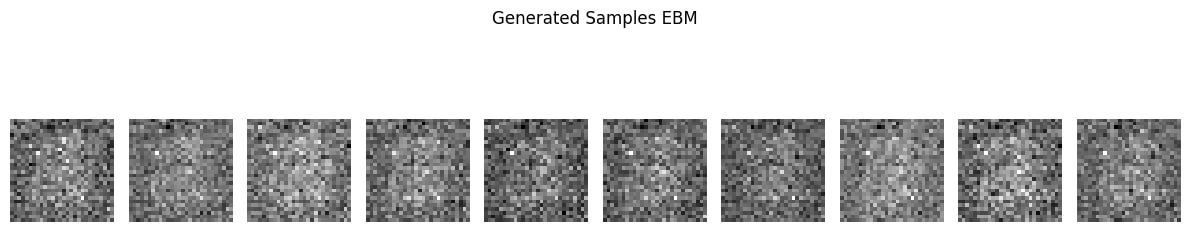

<div dir='rtl' align='justify'>

برای رفع این موضوع دو ایده به ذهنم رسید:

1) در هر استپ لنجوین مقدار هر پیکسل عکس هارو به مقدار بین 0 و 1 مپ کنیم. چون مقدار پیکسل های عکس ها هم در همین فضا هستند.

2) کاهش ابعاد داده ها توسط PCA تا مشکل فرض منیفولد را حل کنیم.

در ادامه دو مدل برای EBM در نظر گرفته شده که در مقایسه های بعدی هم آورده خواهد شد:

EBM with mapping: مدل EBM با مپ کردن در هر استپ لنجوین

EBM with PCA: کاهش ابعاد با PCA و سپس مدل ساده EBM بدون مپ کردن در هر استپ لنجوین
( چون فضای کاهش یافته لزوما بین صفر و یک نیست پس در لنجوین به کاهش بعد نداریم)

همانطور که در روند آموزش این دو مدل میبینیم بر خلاف EBM در حالت عادی ، در این دو مدل مقدار انرژی ها برای داده جنریت شده در هر ایپاک و داده اصلی کاهشی بوده که این نشانگر این است که مدل داره آموزش میبینه واقعا نه که صرفا یک تابع خطایی رو کم کنه.


</div>


## score matching loss functions

In [ ]:
# Exact Hyvärinen score-matching for an energy model:
def hyvarinen_exact_loss(model, x_pos):
    x = x_pos.detach().requires_grad_(True)
    B, D = x.size(0), x[0].numel()

    # First derivative wrt inputs
    E = model(x).view(-1)
    g = torch.autograd.grad(E.sum(), x,
                            create_graph=True,
                            retain_graph=True)[0]
    g_flat = g.view(B, D)
    grad_term = 0.5 * g_flat.pow(2).sum(dim=1)

    # Exact Laplacian: sum of Hessian diagonal
    lap = torch.zeros(B, device=x.device)
    for j in range(D):
        # d g_j / d x : take gradient of the j-th component of g wrt x
        gv = g_flat[:, j]
        hv = torch.autograd.grad(gv.sum(), x,
                                 retain_graph=True,
                                 create_graph=True,
                                 allow_unused=True)[0]
        lap = lap + hv.view(B, D)[:, j]

    return grad_term - lap


In [ ]:
# Score matching loss with  Hutchinson estimate of trace(H_E)
def ism_loss_energy(model, x, probes=5):

    x = x.detach().requires_grad_(True)

    # Energy per sample and its gradient wrt inputs
    E = model(x).view(-1)
    g = torch.autograd.grad(E.sum(), x, create_graph=True)[0]
    grad_sq = 0.5 * g.flatten(1).pow(2).sum(dim=1)

    # Hutchinson estimate of trace(H_E)
    lap = 0.0
    for _ in range(probes):
        # Rademacher noise (±1)
        v = (torch.randint_like(x, 0, 2) * 2 - 1).float()
        gv = (g * v).flatten(1).sum(dim=1)
        Hv = torch.autograd.grad(gv.sum(), x, create_graph=True)[0]  #
        lap = lap + (Hv * v).flatten(1).sum(dim=1)
    lap = lap / probes
    loss = grad_sq - lap
    return loss


## Define the Model's Class

In [ ]:
# needed packages for this task
import torch.nn as nn
import torch.nn.functional as F
import os, time

In [ ]:
class EBM(nn.Module):
    def __init__(self, img_shape=(1, 28, 28), hidden=256):
        super().__init__()
        C,H,W = img_shape
        self.input_dim = C*H*W
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(self.input_dim, hidden*2),
            nn.ReLU(True),
            nn.Linear(hidden*2, hidden),
            nn.ReLU(True),
            nn.Linear(hidden, 1)
          )


    def forward(self, x):
        # forward pass computes f_teta
        return self.net(x)


    def sample(self, num_samples, steps=60, eta=1e-2, mapping=True):

        x = torch.rand(num_samples, self.input_dim, device=device)

        for _ in range(steps):
            x.requires_grad_(True)
            E = self.forward(x).sum()
            g, = torch.autograd.grad(E, x)
            x = x - eta * g + ((2.0 * eta)**0.5) * torch.randn_like(x)
            if mapping:
              x = x.clamp(0.0, 1.0) # mappin part
            x = x.detach()
        return x

## EBM with mapping in langevin


In [ ]:
# model definition
img_shape = X_train.size()[1:]
EBM_model_mapping = EBM(img_shape=img_shape).to(device)

# Optimizer
optimizer = torch.optim.Adam(EBM_model_mapping.parameters(), lr=1e-3, )

# Training params
k = 50  # Langevin steps
eta = 0.01

In [ ]:
# Base drive path
base_path = "/content/drive/MyDrive/experiments/mnist_EBM_with_mapping"
ckpt_path = os.path.join(base_path, "checkpoints")   # path for checkpoints
# sample_path = os.path.join(base_path, "samples")     # path for generated samples
log_path_dir = os.path.join(base_path, "logs")       # path for logs
for d in (ckpt_path, log_path_dir):
    os.makedirs(d, exist_ok=True)

log_path = os.path.join(log_path_dir, "training_log.csv")
with open(log_path, "w") as f:
    f.write("epoch,elapsed_time_s,loss\n")

In [ ]:
# Training loop
epochs = 100

EBM_model_mapping.train()
for epoch in range(1, epochs+1):
    epoch_loss = 0
    start_time = time.time()
    for x_pos in train_loader:
        x_pos = x_pos.to(device)

        # # Score matching
        # loss = ism_loss_energy(EBM_model_mapping, x_pos).mean()

        # CD-k loss
        # Negative samples via Langevin dynamics
        x_neg = EBM_model_mapping.sample(num_samples=x_pos.size(0), steps=k, eta=eta,
                                         mapping=True) # set mapping True to have EBM with mapping
        # Energies
        E_pos = EBM_model_mapping(x_pos).mean() # output of the model has been considered energy (the langeving sampling has been adopted respectively)
        E_neg = EBM_model_mapping(x_neg).mean()
        loss = E_pos - E_neg # loss is difference between energies

        # # CD-k loss with energy regularizer (keeps energies bounded)
        # # Negative samples via Langevin dynamics
        # x_neg = EBM_model_mapping.sample(num_samples=x_pos.size(0), steps=k, eta=eta, use_replay=True) # we set it true just during training
        # E_pos = EBM_model_mapping(x_pos).mean() # output of the model has been considered energy
        # E_neg = EBM_model_mapping(x_neg).mean()
        # loss = E_pos - E_neg
        # loss = loss + 1e-3 * (E_pos**2 + E_neg**2)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    elapsed = time.time() - start_time
    epoch_loss = epoch_loss / len(train_loader)


    # print(f"epoch {epoch:03d} loss={epoch_loss:.4f}") # results of Score matching (in case you used score matching method)
    print(f"epoch {epoch:03d} loss={epoch_loss:.4f} | Energy_pos={E_pos:.4f} | Energy_neg={E_neg:.4f}") # results of CD
    with open(log_path, "a") as f:
          f.write(f"{epoch},{elapsed:.2f},{loss:.6f}\n")


print("Training complete.")

# Save checkpoint
torch.save(EBM_model_mapping.state_dict(), os.path.join(ckpt_path, f"EBM_with_mapping_epoch{epoch:03d}.pt"))

epoch 001 loss=-27.2900 | Energy_pos=-10.3338 | Energy_neg=75.4385
epoch 002 loss=-270.1086 | Energy_pos=-109.5163 | Energy_neg=338.6058
epoch 003 loss=-382.7285 | Energy_pos=-246.5067 | Energy_neg=-11.0132
epoch 004 loss=-92.6789 | Energy_pos=8.5673 | Energy_neg=60.8855
epoch 005 loss=-4.9630 | Energy_pos=177.3393 | Energy_neg=170.0311
epoch 006 loss=-0.9763 | Energy_pos=166.5084 | Energy_neg=159.6242
epoch 007 loss=-9.7210 | Energy_pos=120.7711 | Energy_neg=171.0964
epoch 008 loss=-9.4889 | Energy_pos=130.4895 | Energy_neg=155.0827
epoch 009 loss=-17.4554 | Energy_pos=123.3052 | Energy_neg=152.6715
epoch 010 loss=-17.9143 | Energy_pos=69.5768 | Energy_neg=131.3938
epoch 011 loss=-19.0259 | Energy_pos=98.8391 | Energy_neg=133.0928
epoch 012 loss=-24.2580 | Energy_pos=115.7496 | Energy_neg=137.5816
epoch 013 loss=-24.4598 | Energy_pos=109.9674 | Energy_neg=121.3714
epoch 014 loss=-29.2487 | Energy_pos=106.3682 | Energy_neg=116.8837
epoch 015 loss=-28.7843 | Energy_pos=84.3097 | Energy_

## EBM with PCA

In [ ]:
from sklearn.decomposition import PCA

In [ ]:
n_components = 35
pca = PCA(n_components=n_components)
X_train_transformed = pca.fit_transform(X_train.view(X_train.size(0), -1).numpy())
X_train_transformed = torch.from_numpy(X_train_transformed).float()
X_transformed_loader = DataLoader(X_train_transformed, batch_size=64, shuffle=True)

In [ ]:
pca.explained_variance_ratio_.sum()

np.float32(0.6700547)

In [ ]:
# model definition
img_shape = [1,1,X_train_transformed.size(-1)]
EBM_model_pca = EBM(img_shape=img_shape, ).to(device)

# Optimizer
optimizer = torch.optim.Adam(EBM_model_pca.parameters(), lr=1e-3, )

# Training params
k = 50  # Langevin steps
eta = 0.01

In [ ]:
# Base drive path
base_path = "/content/drive/MyDrive/experiments/mnist_EBM_with_PCA"
ckpt_path = os.path.join(base_path, "checkpoints")   # path for checkpoints
# sample_path = os.path.join(base_path, "samples")     # path for generated samples
log_path_dir = os.path.join(base_path, "logs")       # path for logs
for d in (ckpt_path, log_path_dir):
    os.makedirs(d, exist_ok=True)

log_path = os.path.join(log_path_dir, "training_log.csv")
with open(log_path, "w") as f:
    f.write("epoch,elapsed_time_s,loss\n")

In [ ]:
# Training loop
epochs = 100

EBM_model_pca.train()
for epoch in range(1, epochs+1):
    epoch_loss = 0
    start_time = time.time()
    for x_pos in X_transformed_loader:
        x_pos = x_pos.to(device)

        # # Score matching
        # loss = ism_loss_energy(EBM_model_pca, x_pos).mean()

        # CD-k loss
        # Negative samples via Langevin dynamics
        x_neg = EBM_model_pca.sample(num_samples=x_pos.size(0), steps=k, eta=eta,
                                     mapping=False )  # set mapping false to avoid mapping for latter comparison
        # Energies
        E_pos = EBM_model_pca(x_pos).mean() # output of the model has been considered energy (the langeving sampling has been adopted respectively)
        E_neg = EBM_model_pca(x_neg).mean()
        loss = E_pos - E_neg # loss is difference between energies

        # # CD-k loss with energy regularizer (keeps energies bounded)
        # # Negative samples via Langevin dynamics
        # x_neg = EBM_model_pca.sample(num_samples=x_pos.size(0), steps=k, eta=eta, use_replay=True) # we set it true just during training
        # E_pos = EBM_model_pca(x_pos).mean() # output of the model has been considered energy
        # E_neg = EBM_model_pca(x_neg).mean()
        # loss = E_pos - E_neg
        # loss = loss + 1e-3 * (E_pos**2 + E_neg**2)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    elapsed = time.time() - start_time
    epoch_loss = epoch_loss / len(train_loader)


    # print(f"epoch {epoch:03d} loss={epoch_loss:.4f}") # results of Score matching (in case you used score matching method)
    print(f"epoch {epoch:03d} loss={epoch_loss:.4f} | Energy_pos={E_pos:.4f} | Energy_neg={E_neg:.4f}") # results of CD
    with open(log_path, "a") as f:
          f.write(f"{epoch},{elapsed:.2f},{loss:.6f}\n")


print("Training complete.")

# Save checkpoint
torch.save(EBM_model_pca.state_dict(), os.path.join(ckpt_path, f"EBM_with_PCA_epoch{epoch:03d}.pt"))

epoch 001 loss=-2.5454 | Energy_pos=-2.0164 | Energy_neg=2.2160
epoch 002 loss=-0.4166 | Energy_pos=-9.4746 | Energy_neg=-11.6934
epoch 003 loss=-0.0129 | Energy_pos=-15.4775 | Energy_neg=-12.4332
epoch 004 loss=-1.6914 | Energy_pos=-18.4555 | Energy_neg=-18.1814
epoch 005 loss=-0.8718 | Energy_pos=-20.9261 | Energy_neg=-23.3895
epoch 006 loss=-1.8769 | Energy_pos=-25.6741 | Energy_neg=-22.4580
epoch 007 loss=-1.2885 | Energy_pos=-25.4434 | Energy_neg=-19.9496
epoch 008 loss=-0.6193 | Energy_pos=-20.3802 | Energy_neg=-22.4630
epoch 009 loss=-1.6254 | Energy_pos=-19.9275 | Energy_neg=-18.0441
epoch 010 loss=-1.3691 | Energy_pos=-22.2414 | Energy_neg=-17.6144
epoch 011 loss=0.0381 | Energy_pos=-19.4893 | Energy_neg=-21.2123
epoch 012 loss=-2.4347 | Energy_pos=-21.3479 | Energy_neg=-16.3500
epoch 013 loss=-1.6877 | Energy_pos=-22.9145 | Energy_neg=-20.8964
epoch 014 loss=-1.1911 | Energy_pos=-22.2692 | Energy_neg=-17.6823
epoch 015 loss=-1.8495 | Energy_pos=-20.7528 | Energy_neg=-18.0985


# Task 5: Generation
- Generate 1,000 samples for all the three trained above model
- Use the same random seed as Assignment 3
<div dir='rtl' align='justify'>
 random seed ها اول نوت بوک به همون  random seed های تمرین قبل ست شدند. پس نتایج و آموزش مدل ها دقیقا با همان  random seed و نتایج تمرین قبل است.
</div>

In [ ]:
# generate 1000 samples using NICE
NICE_model.eval()
final_NICE_samples = NICE_model.sample(1000).cpu().numpy()

In [ ]:
# generate 1000 samples using GAN
gan.eval()
final_GAN_samples = gan.generate(1000).cpu().numpy()

In [ ]:
# generate 1000 samples using EBM with mapping
EBM_model_mapping.eval()
final_EBM_mapping_samples = EBM_model_mapping.sample(1000, steps=k, eta=eta, mapping=True).cpu().detach().numpy()

In [ ]:
# generate 1000 samples using EBM with PCA
EBM_model_pca.eval()
final_EBM_pca_samples = EBM_model_pca.sample(1000, steps=k, eta=eta, mapping=False).cpu().detach().numpy()
final_EBM_pca_samples = torch.tensor(pca.inverse_transform(final_EBM_pca_samples))


# Task 6: Verification:
- Print 10 random samples for each model


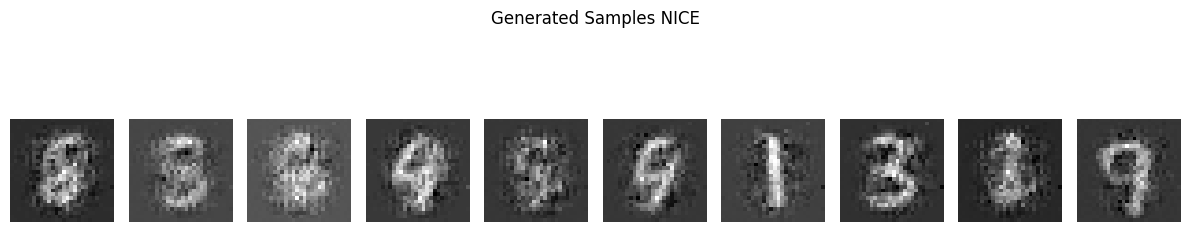

In [ ]:
# Randomly choose 10 sample from NICE model and visualize
plt.figure(figsize=(12, 3))
for i in range(10):
    plt.subplot(1, 10, i+1)
    plt.imshow(final_NICE_samples[torch.randperm(len(final_NICE_samples))[:10]][i].reshape(28, 28), cmap='gray')
    plt.axis('off')
plt.suptitle(f"Generated Samples NICE")
plt.tight_layout()
plt.show()

- Are digits recognizable?
  <div dir='rtl' align='justify'>
   بله برخی از ارقام مانند 1 و 3 و 9 نسبتا واضح و قابل تشخیص اند.ولی بعضی ارقام مثل 0، 2، 5 و 8 مبهم اند و مانند یک دایره بلوری وسط تصویر قرار دارند. این بخاطر اینه که مدل سخت توانسته این ارقام رو از هم تفکیک بدهد و به جاش از میانگین این ارقام برای جنریت کردن هر یک از اینا به نحوی استفاده کرده. و چون توزیع فضای پنهان گوسی است در موارد عدم قطعیت این میانگین به شکل هاله دایره شکل بلوری دیده میشود. در مورد اعداد 1 و 3 و 9 هم که حتی واضح تر اند هم این مسپله توی موارد عدم قطعیت واضحه
  </div>

- Any systematic artifacts?
  <div dir='rtl' align='justify'>
  به طور کلی در تصاویر تولید شده یک هاله بلوری و نویزی به شکل گرد داخل تصاویر مشخص است. این بخاطر این است که در داده MNIST اولا چون همه ارقام در مرکز تصویر اند این هاله در مرکز تصویر است. چون میانگین تصاویر یک تصویر شبیه مرکز حدودا سفید خاکستری و حاشیه های سیاه میشود. دوما دلیل گرد بودن این هاله و نویز این است که تصاویر از یه فضای پنهان گوسی میایند. در فضای گوسی توزیع شکل گرد دارد و فاصله از میانگین در شعاع آن برابر است. در نتیجه این مسئله در تصاویر تولید شده نیز خود را نمایش داده و نویز ها به صورت گرد در مرکز تصویر قرار داده شده اند. یعنی تصاویر دارای نویز گرد وسط تصویرند که به دو دلیل توزیع گوسی در فضای پنهان و محل قرار گیری ارقام در مرکز تصویر هست.
  </div>
- Comment on comparing visibly these generated samples to what you had in Assignment 3.
  <div dir='rtl' align='justify'>
 در مقایسه با VAE، ارقام NICE کمتر صاف هستند و نویز بیشتری دارند. VAE حالت بلوری دارد اما در کل ارقام قابل تشخیص تر هستند.
 در مقایسه با NADE، ارقام NICE ساختار یافته تر و قابل تشخیص تر  هستند. چون NADE بخاطر حالت اتورکرسیوش به پیکسلای بعد نگاه نمیکرد.


  </div>

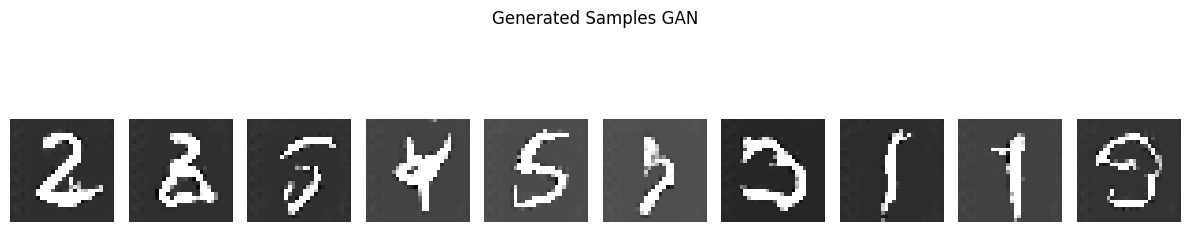

In [ ]:
# Randomly choose 10 sample from GAN model and visualize
plt.figure(figsize=(12, 3))
for i in range(10):
    plt.subplot(1, 10, i+1)
    plt.imshow(final_GAN_samples[torch.randperm(len(final_GAN_samples))[:10]][i].reshape(28, 28), cmap='gray')
    plt.axis('off')
plt.suptitle(f"Generated Samples GAN")
plt.tight_layout()
plt.show()

- Are digits recognizable?
  <div dir='rtl' align='justify'>
 اکثر ارقام مانند 9، 1 و 5 واضح اند اما بعضی رقم های ناقص یا بی معنی وجود دارد.
  </div>

- Any systematic artifacts?
  <div dir='rtl' align='justify'>
  خطوط شکسته یا از بین رفته وجود دارد. مثلا تصویر چهارمی از راست یک سه بدون یک دندانه است. از طرفی در بعضی ارقام خطوط اضافی وجود دارد مثلا دومین رقم از چپ شبیه 6 است ولی یک شیش نرمال نیست  این میتونه به این دلیل باشه که آموزش گن ناپایدار است و Generator راه آسان تری برای گول زدن Descriminator پیدا میکنه که  تولید این شکل ها راحت تر از تولید عدد واقعی است اما برای Descriminator سخته اون رو از نمونه واثعی تشخیص بدهد.

  mode colapse در تصاویر دیده میشود. مثلا رقم ۱ در مقایسه با ارقام دیگه بسیار واضح تر و بیشتر وجود دارد. مثلا اصلا رقم 7 یا 8 دیده نمیشود ولی 1 خیلی هست. دلیل این هم این است که generator براش تولید بعضی ارقام راحت تر و آسان تر است. پس به جای پوشش همه ارقام به طور مساوی رو اونا تمرکز میکنه تا راحت تر descriminator رو گول بزنه. (من یه دور با مدل ساده تر mlp که ترین کردم این mode colapse خیلی اثرش بیشتر بود فک کنم چون مدل ساده تر بود و یادگیری ارقام پیچیده براش سخت بود پس فقط با یه رقم میخواست desrciminator رو گول بزنه.
  </div>
- Comment on comparing visibly these generated samples to what you had in Assignment 3.
  <div dir='rtl' align='justify'>
  در مقایسه با VAE، ارقام GAN واضح تر ولی اکثرا  شکسته یا ناخوانا هستند. VAE رقم های تارتر ولی کامل تری تولید میکند. در مقایسه با NICE، ارقام GAN نویز کمتری دارند و گاهی اوقات تمیزتر هستند، اما همیشه ثابت نیستند.  GAN در مقایسه با NADE به وضوح بهتر دارد. چون تصاویر NADE اکثرا قابل تشخیص نبودند ولی GAN به طور کلی تصاویر تمیز تری میدهد.


  </div>

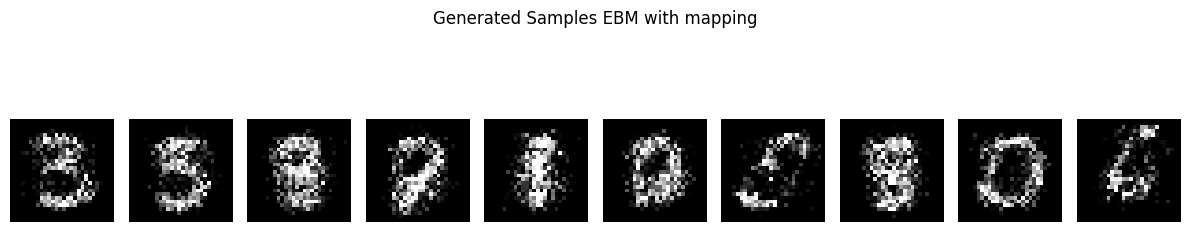

In [ ]:
# Randomly choose 10 sample from EBM model and visualize
plt.figure(figsize=(12, 3))
for i in range(10):
    plt.subplot(1, 10, i+1)
    plt.imshow(final_EBM_mapping_samples[torch.randperm(len(final_EBM_mapping_samples))[:10]][i].reshape(28, 28), cmap='gray')
    plt.axis('off')
plt.suptitle(f"Generated Samples EBM with mapping")
plt.tight_layout()
plt.show()

- Are digits recognizable?
  <div dir='rtl' align='justify'>
بله برخی از ارقام تا حدی قابل تشخیص هستند. به عنوان مثال اشکالی شبیه به 3، 5، 6 و 0 قابل مشاهده هستند، اگرچه هنوز نویز دارند. با این حال نسبت به EBM بدون مپینگ که فقط تویز جنریت میکرد بسیار بهتر است. دلیل آن هم همگرایی بهتر الگوریتم لنجوین است که نقش مهمی در آموزش و نمونه گیری از EBM دارد.
  </div>

- Any systematic artifacts?
  <div dir='rtl' align='justify'>
همچنان نویز قابل توجهی در اطراف ارقام دیده میشود و بعضی ارقام ترکیب شده، نا مفهوم یا ید شکل هستند. که این به این دلیل است که همچنان مشکل منیفولد در داده ها وجود دارد و اسکور در بعضی نواحی وجود ندارد پس مدل نمیتواند به خوبی نویز رو از اون نواحی هدایت کند.

  
  </div>
- Comment on comparing visibly these generated samples to what you had in Assignment 3.
  <div dir='rtl' align='justify'>
در مقایسه با VAE مدل EBM با مپینگ هنوز ضعیف تر است. چون VAE اعداد واضح تری تولید میکرد. ولی که EBM با مپینگ همچنان نویز و شکل‌های نصفه نیمه تولید میکنه. با این حال، نسبت به NADE خیلی بهتر عمل میکند، چون نمونه های NADE نویز های پراکنده بیشتری داشتند. ولی در EBM با مپینگ این نویز ها کمتر و اعداد شکل بهتری دارند.

  </div>

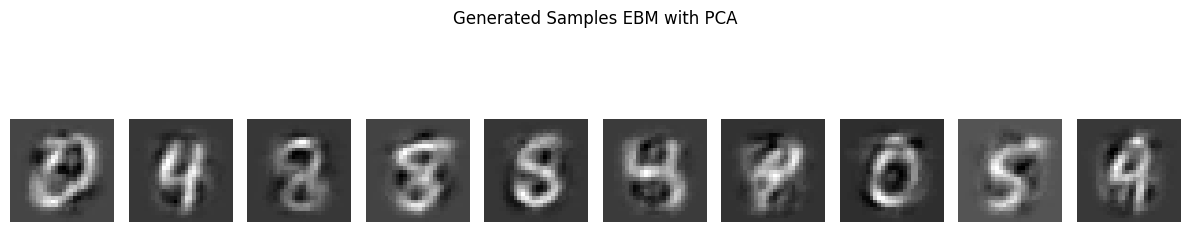

In [ ]:
# Randomly choose 10 sample from EBM model and visualize
plt.figure(figsize=(12, 3))
for i in range(10):
    plt.subplot(1, 10, i+1)
    plt.imshow(final_EBM_pca_samples[torch.randperm(len(final_EBM_pca_samples))[:10]][i].reshape(28, 28), cmap='gray')
    plt.axis('off')
plt.suptitle(f"Generated Samples EBM with PCA")
plt.tight_layout()
plt.show()

- Are digits recognizable?
  <div dir='rtl' align='justify'>
بله اعداد نسبت به EBM اصلی و حتی EBM با مپینگ خیلی بهتر قابل تشخیص‌اند. برای مثال، اعداد 4، 5، 0 و 8 تا حد زیادی مشخص اند هرچند بعضی هنوز یکم تار دیده میشوند.
</div>

- Any systematic artifacts?
  <div dir='rtl' align='justify'>
در مدل EBM با PCA اعداد خیلی قابل تشخیص تر شدند، ولی هنوز خیلی از اعداد یکم تار به نظر میرسند. چون PCA ابعاد را کاهش میده و جزئیات ریز را اسموت تر میکنه و فقط ساختار کلی رو حفظ میکنه. بعضی از اعداد هم انگار روی هم افتادن یا بد فرم هستن. چون PCA بعضی تغییرات را خلاصه میکنه و باعث میشه EBM نتواند ارقام رو به طور طبیعی بازسازی کنه. در آخر هنوز نویز  در پس زمینه دیده میشود چون فرآیند جنریت کردن لنجوین همچنان خوب همگرا نمیشه.
  </div>
- Comment on comparing visibly these generated samples to what you had in Assignment 3.
  <div dir='rtl' align='justify'>
در مقایسه با NADE ارقام بسیار واضح تر و بهتر است. ولی در مقایسه با VAE مثل اون این هم نویزی است. چون این هم به یک طریقی درستنمایی فضای پنهان که از طریق PCE بدست اومده رو پیدا میکنه نه خود دیتای اصلی. ولی همچنان VAE رقم های مشخص تری رو تولید میکرد.

  </div>

# Task 7: Sample quality metrics:
- Compute the following metrics for the generated samples of each model
  - Inception score (IS)
  - Fréchet Inception Distance (FID)
  - Kernel Inception Distance (KID)
- Create a table of
  - Calculated above metrics for each model
  - Add the calculated metrics for VAE and NADE from assignment 3
  - Comment on results



### <div dir='rtl' align='justify'> جدول مقایسه همه مدل ها ( این تمرین و تمرین قبل) از نظر معیار های بالا: </div>

|index|IS|FID|KID|
|---|---|---|---|
|NICE|4\.598|197\.052|492\.153|
|GAN|7\.087|30\.437|97\.704|
|EBM with Mapping|4\.9|219\.84|543\.555|
|EBM with PCA|7\.367|45\.901|140\.373|
|GMM|4\.76|208\.392|517\.162|
|NADE|4\.389|181\.151|422\.694|
|VAE|7\.24|110\.359|318\.398|


  <div dir='rtl' align='justify'>

  - مدل GAN بهترین نتایج رو داره چون تصاویری که تولید کرده شارپ و شبیه به ارقام واقعی هستند و classifier در IS با اطمینان آن‌ها را تشخیص می‌دهد. ویژگی های کلی مثل ضخامت و کنتراست خطوط نیز به داده اصلی نزدیک است که باعث شده مقادیر KID و FID کمی داشته باشد. البته خط های ناخوانا و گرایش به تولید برخی ارقام بیشتر از بقیه باعث شده حتی مدل نتیحه بهتری نگیرد.

  - مدل EBM with PCA نتایج بسیار خوبی نسبت به دیگر نسخه‌های EBM دارد و IS بالایی نزدیک به GAN به دست آورده است. دلیلش این است که با PCA مشکل فرض منیفولد تا حدودی رفع شده و جلوی ناپدید شدن اسکور و نویزی موندن داده ها رو میگیره. هرچند همچنان FID و KID آن بالاتر از GAN است اون هم چون بعضی ویژگی ها توسط پی سی ای خلاصه شدند.

  - مدل VAE نیز امتیاز IS بالایی دارد چون ارقام تولید شده معمولا در همه کلاس ها قابل تشخیص هستند.ولی تار بودن خروجی ها باعث میشود فضای ویژگی نمونه ها از فضای ویژگی داده واقعی دور شوند. به همین دلیل FID و KID آن نسبت به GAN خیلی بیشتر است، با اینکه اعداد قابل شناسایی اند.

  - مدل NADE کیفیت پایینی دارد. خروجی‌ها به شکل پراکنده و پیکسلی هستند و اعداد به سختی قابل تشخیص اند. همین ساختار ضعیف باعث شده هم IS پایین باشد و هم FID و KID بالا باشد.

  - مدل NICE امتیاز IS پایین تر و FID و KID بالاتری دارد چون اعداد تولید شده اغلب دچار نویز و هاله های اطراف ارقام هستند که قطعیت classifier رو پایین میاورد. همین آرتیفکت‌ها توزیع ویژگی‌ها را تغییر میدهند و بخاط همین فضای ویژگی از ویژگی داده اصلی دور میشه. نتایج این مدل خیلی شبیه GMM است. در GMM هم نمونه‌ ها حالت محو دارند و انگار یک هاله روی آنهاست برای همین نتیجه NICE و GMM مشابه هم اند.
  - مدل‌های NADE و EBM همگی کیفیت پایینی دارند. در NADE خروجی‌ها به شکل پراکنده هستند و اعداد به سختی قابل تشخیص اند، EBM بدترین عملکرد را دارد و خروجی‌های آن عملا نویز اند.
  - مدل EBM with Mapping نسبت به EBM ساده عملکرد بهتری نشان داده چون  mapping باعث میشود لنجوین همگرا شود و مدل آموزش ببیند و د نتیجه نویز تولید نکرده  پس IS آن معقول است و تصاویر خوب بودند ولی از همه مدل های بدتر عمل کرده است.  همچنان به دلیل وجود نویز و ساختارهای ناقص، مقادیر FID و KID بالا هستند و کیفیت خروجی ضعیف است.
  </div>

## Load LeNet

In [ ]:
# clone pre-trained LeNet for the MNIST dataset from GitHub
!git clone https://github.com/csinva/gan-vae-pretrained-pytorch.git
!cd gan-vae-pretrained-pytorch

Cloning into 'gan-vae-pretrained-pytorch'...
remote: Enumerating objects: 193, done.
remote: Counting objects: 100% (6/6), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 193 (delta 0), reused 0 (delta 0), pack-reused 187 (from 1)
Receiving objects: 100% (193/193), 100.76 MiB | 25.06 MiB/s, done.
Resolving deltas: 100% (71/71), done.


In [ ]:
import torch.nn as nn
from collections import OrderedDict

In [ ]:
# Copied the LeNet model class from its GitHub repository
class LeNet5(nn.Module):
    """
    Input - 1x32x32
    C1 - 6@28x28 (5x5 kernel)
    tanh
    S2 - 6@14x14 (2x2 kernel, stride 2) Subsampling
    C3 - 16@10x10 (5x5 kernel, complicated shit)
    tanh
    S4 - 16@5x5 (2x2 kernel, stride 2) Subsampling
    C5 - 120@1x1 (5x5 kernel)
    F6 - 84
    tanh
    F7 - 10 (Output)
    """
    def __init__(self):
        super(LeNet5, self).__init__()

        self.convnet = nn.Sequential(OrderedDict([
            ('c1', nn.Conv2d(1, 6, kernel_size=(5, 5))),
            ('relu1', nn.ReLU()),
            ('s2', nn.MaxPool2d(kernel_size=(2, 2), stride=2)),
            ('c3', nn.Conv2d(6, 16, kernel_size=(5, 5))),
            ('relu3', nn.ReLU()),
            ('s4', nn.MaxPool2d(kernel_size=(2, 2), stride=2)),
            ('c5', nn.Conv2d(16, 120, kernel_size=(5, 5))),
            ('relu5', nn.ReLU())
        ]))

        self.fc = nn.Sequential(OrderedDict([
            ('f6', nn.Linear(120, 84)),
            ('relu6', nn.ReLU()),
            ('f7', nn.Linear(84, 10)),
            ('sig7', nn.LogSoftmax(dim=-1) )
        ]))

    def forward(self, img):
        output = self.convnet(img)
        output = output.view(img.size(0), -1)
        output = self.fc(output)
        return output

In [ ]:
# Load the model weights from the cloned repository
net = LeNet5().eval()
net.load_state_dict(torch.load('/content/gan-vae-pretrained-pytorch/mnist_classifier/weights/lenet_epoch=12_test_acc=0.991.pth'))


<All keys matched successfully>

In [ ]:
import torch.nn.functional as F

In [ ]:
# Pad the train image to 32x32
padded_input = F.pad(X_train, (2, 2, 2, 2), "constant", 0)

# Evaluate model on train dataset
preds = net(padded_input).detach().numpy()
class_preds = np.argmax(preds, axis=1)
print('test acc', sum(class_preds == y_train) / 1000)

test acc tensor(0.9800)


In [ ]:
# Pad the test image to 32x32
padded_input = F.pad(X_test, (2, 2, 2, 2), "constant", 0)

# Evaluate model on test dataset
preds = net(padded_input).cpu().detach().numpy()
class_preds = np.argmax(preds, axis=1)
print('test acc', sum(class_preds == y_test) / len(y_test))

test acc tensor(0.9770)


## Metrics Calculation

In [ ]:
def inception_score(X, classifier):
    # check if data is tensor
    X = torch.as_tensor(X, dtype=torch.float32)
    # pad input to match LeNet dimension
    padded_input = F.pad(X.view(-1,1,28,28), (2, 2, 2, 2), "constant", 0)

    # get classes probabilities
    probs = torch.exp(classifier(padded_input)) # LeNet output is logSoftmax
    # LeNet outputs which is log probabilities
    log_probs = classifier(padded_input)

    # Compute sharpness
    sharpness = torch.exp(torch.mean(torch.sum(probs*log_probs, dim=1))).item()

    # compute diversity
    c_y = torch.mean(probs,dim=0)
    diversity = torch.exp(-torch.mean(torch.matmul(probs, torch.log(c_y+1e-6)))).item()

    # Inception Score
    IS = diversity * sharpness

    return round(sharpness,3), round(diversity,3), round(IS,3)

In [ ]:
from scipy.linalg import sqrtm
from scipy.stats import multivariate_normal

In [ ]:
# function for extract feature from LeNet
def LeNetFeatureExtractor(img, model=net):

        output = model.convnet(img)
        output = output.view(img.size(0), -1)
        output = model.fc[:3](output)

        return output

In [ ]:
def fid_score(X_test, X_generated,feature_extractor):
    # check if data is tensor
    X_generated = torch.as_tensor(X_generated, dtype=torch.float32)

    # Pad generated and test datasets for LeNet
    fake_padded_input = F.pad(X_generated.view(-1,1,28,28), (2, 2, 2, 2), "constant", 0)
    real_padded_input = F.pad(X_test, (2, 2, 2, 2), "constant", 0)

    # Extact features (using prefinal layer of LeNet)
    fake_input = feature_extractor(fake_padded_input).detach().numpy()
    real_input = feature_extractor(real_padded_input).detach().numpy()

    # Fit gaussian distribution
    mu_fake, sigma_fake = multivariate_normal.fit(fake_input)
    mu_real, sigma_real = multivariate_normal.fit(real_input)
    mu_diff = mu_real - mu_fake

    # Compute (sigma_real*sigma_fake)^1/2
    covmean = sqrtm(sigma_real.dot(sigma_fake))
    if np.iscomplexobj(covmean):
        covmean = covmean.real

    # compute FID score
    fid = mu_diff.dot(mu_diff) + np.trace(sigma_real + sigma_fake - 2 * covmean)
    return round(fid.item(),3)

In [ ]:
from sklearn.metrics.pairwise import polynomial_kernel

In [ ]:
def kid_score(X_test, X_generated,feature_extractor,degree=2, gamma=0.1):

    # check if data is tensor
    X_generated = torch.as_tensor(X_generated, dtype=torch.float32)

    # Pad generated and test datasets for LeNet
    fake_padded_input = F.pad(X_generated.view(-1,1,28,28), (2, 2, 2, 2), "constant", 0)
    real_padded_input = F.pad(X_test, (2, 2, 2, 2), "constant", 0)

    # Extact features (using prefinal layer of LeNet)
    fake_input = feature_extractor(fake_padded_input).detach().numpy()
    real_input = feature_extractor(real_padded_input).detach().numpy()

    m = real_input.shape[0]
    n = fake_input.shape[0]

    # Comput similarity matices
    Kxx = polynomial_kernel(real_input, real_input, degree=degree, gamma=gamma)
    Kyy = polynomial_kernel(fake_input, fake_input, degree=degree, gamma=gamma)
    Kxy = polynomial_kernel(real_input, fake_input, degree=degree, gamma=gamma)

    # fill Kxx and Kyy diagonals with zero because we don't care about each samples similarity by itself
    np.fill_diagonal(Kxx, 0)
    np.fill_diagonal(Kyy, 0)

    mmd = (Kxx.sum() / (m * (m - 1)) #divide by the number of off-diagonal pairs
            + Kyy.sum() / (n * (n - 1))  #divide by the number of off-diagonal pairs
            -  2*Kxy.mean())
    return round(float(mmd),3)

In [ ]:
import pandas as pd

In [ ]:
# compute and organize metrics for all three models
metrics = {'IS':[inception_score(final_NICE_samples,net)[-1],
                 inception_score(final_GAN_samples,net)[-1],
                 inception_score(final_EBM_mapping_samples,net)[-1],
                 inception_score(final_EBM_pca_samples,net)[-1]],
           'FID':[fid_score(X_test, final_NICE_samples,LeNetFeatureExtractor),
                  fid_score(X_test, final_GAN_samples,LeNetFeatureExtractor),
                  fid_score(X_test, final_EBM_mapping_samples,LeNetFeatureExtractor),
                  fid_score(X_test, final_EBM_pca_samples,LeNetFeatureExtractor)],
           'KID':[kid_score(X_test, final_NICE_samples,LeNetFeatureExtractor),
                  kid_score(X_test, final_GAN_samples,LeNetFeatureExtractor),
                  kid_score(X_test, final_EBM_mapping_samples,LeNetFeatureExtractor),
                  kid_score(X_test, final_EBM_pca_samples,LeNetFeatureExtractor)]}
metrics = pd.DataFrame(metrics,index=['NICE','GAN','EBM with Mapping', 'EBM with PCA'])

In [ ]:
print('Results:')
metrics

Results:


,IS,FID,KID
NICE,4.598,197.052,492.153
GAN,7.087,30.437,97.704
EBM with Mapping,4.900,219.840,543.555
EBM with PCA,7.367,45.901,140.373


# Task 8: Computation Trade-offs

## Compare training time of all the 5 trained models (this assignment and Assignment 3)
  - If you trained a model for more epochs than needed, estimate training time
based on only the required number of epochs. This makes comparison less
subjective.

<div dir='rtl' align='justify'>

در مقایسه نهایی چون EBM ها با صد ایپاک آموزش داده شده بود، مقایسه با صد ایپاک اول انجام شده. که در آن VAE سریع ترین مدل و بعد از آن GAN سریع ترین است و اختلاف قابل توجهی با بقیه مدلها دارد. NADE  کند ترینه بخاطر ساختار اتورگرسیوی که داره. البته در حالت کلی EBM ها از NICE کند ترند. ولی چون در NICE مدل پیچیده تری نیاز بود تا سمپل واضح تر گرفته بشه مدل پیچیده شد و کمی از EBM ها کند تر شد.
 </div>

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# Paths
nice_path = "/content/drive/MyDrive/experiments/mnist_NICE/logs"
gan_path  = "/content/drive/MyDrive/experiments/mnist_GAN/logs"
ebm1_path  = "/content/drive/MyDrive/experiments/mnist_EBM_with_mapping/logs"
ebm2_path  = "/content/drive/MyDrive/experiments/mnist_EBM_with_PCA/logs"
vae_path  = "/content/drive/MyDrive/experiments/mnist_vae/logs"
nade_path = "/content/drive/MyDrive/experiments/mnist_nade/logs"

# Dictionary of all models and their paths
model_paths = {
    "NICE": nice_path,
    "GAN": gan_path,
    "EBM with Mapping": ebm1_path,
    "EBM with PCA": ebm2_path,
    "VAE": vae_path,
    "NADE": nade_path
}

# Load all logs into a dictionary
logs = {}
for model, path in model_paths.items():
    csv_file = os.path.join(path, "training_log.csv")
    logs[model] = pd.read_csv(csv_file)


# Function to calculate training time
def estimate_training_time(df, required_epochs=100):
    if required_epochs is None or required_epochs > df["epoch"].max():
        required_epochs = df["epoch"].max()
    time_df = df[:required_epochs]
    avg_epoch_time = time_df["elapsed_time_s"].mean()
    total_time = time_df["elapsed_time_s"].sum()

    return total_time/60, avg_epoch_time

# Collect training times
training_times = {}
for model, df in logs.items():
    total_time, avg_epoch_time = estimate_training_time(df)
    training_times[model] = {
        "epochs_trained": df["epoch"].max(),
        "avg_epoch_time(s)": avg_epoch_time,
        "total_time_100_epoch(m) ": total_time
    }


training_df = pd.DataFrame(training_times).T
print("\nTraining Time Comparison:")
display(training_df)


Training Time Comparison:


,epochs_trained,avg_epoch_time(s),total_time_100_epoch(m)
NICE,500.0,0.9794,1.632333
GAN,250.0,0.3809,0.634833
EBM with Mapping,100.0,0.6941,1.156833
EBM with PCA,100.0,0.6654,1.109000
VAE,250.0,0.0541,0.090167
NADE,250.0,7.8388,13.064667


## Compare sampling time of all the 5 trained models

<div dir='rtl' align='justify'>

در سرعت نمونه تولید کردن هم VAE از همه مدل ها سریع ترین بوده و حتی از baseline یعنی GMM نیز بهتر عمل کرده.
</div>

In [ ]:
import time

Time for 1 sample

In [ ]:
# Time for generate one sample using each model
start_time = time.time()
one_sample = NICE_model.sample(1).cpu().numpy() # generate 1 sample using NICE
Time_one_smple_nice = time.time() - start_time

start_time = time.time()
one_sample = gan.generate(1).cpu().numpy() # generate 1 sample using GAN
Time_one_smple_gan = time.time() - start_time

start_time = time.time()
one_sample = EBM_model_mapping.sample(1).cpu().detach().numpy() # generate 1 sample using EBM
Time_one_smple_ebm_mapping = time.time() - start_time

start_time = time.time()
one_sample = EBM_model_pca.sample(1).cpu().detach().numpy() # generate 1 sample using EBM
Time_one_smple_ebm_pca = time.time() - start_time

start_time = time.time()
z_1 = torch.randn(1, VAE_model.encoder.mu.out_features).to(device)
one_sample = VAE_model.decoder(z_1).cpu() # generate 1 sample using VAE
Time_one_smple_vae = time.time() - start_time

start_time = time.time()
one_sample = NADE_model.generate_samples(1).cpu().numpy() # generate 1 sample using NADE
Time_one_smple_nade = time.time() - start_time

start_time = time.time()
one_sample = gmm.sample(n_samples=1)[0] # generate 1 sample using GMM
Time_one_smple_gmm = time.time() - start_time

In [ ]:
import pandas as pd

In [ ]:
# Make comparison table
sampling_times = {
    "NICE": Time_one_smple_nice,
    "GAN": Time_one_smple_gan,
    "EBM with Mapping": Time_one_smple_ebm_mapping,
    "EBM with PCA": Time_one_smple_ebm_pca,
    "VAE": Time_one_smple_vae,
    "NADE": Time_one_smple_nade,
    'GMM' : Time_one_smple_gmm
}

sampling_df = pd.DataFrame([sampling_times],index=['time for one sample']).T
print("Sampling Time Comparison:")
display(sampling_df)

Sampling Time Comparison:


,time for one sample
NICE,0.023260
GAN,0.005995
EBM with Mapping,0.050819
EBM with PCA,0.045274
VAE,0.000245
NADE,93.429511
GMM,0.000811


Time for 100 samples

In [ ]:
# Time for generate 100 sample using each model
start_time = time.time()
sample = NICE_model.sample(1).cpu().numpy() # generate 100 sample using NICE
Time_100_smple_nice = time.time() - start_time

start_time = time.time()
sample = gan.generate(1).cpu().numpy() # generate 100 sample using GAN
Time_100_smple_gan = time.time() - start_time

start_time = time.time()
sample = EBM_model_mapping.sample(1).cpu().detach().numpy() # generate 100 sample using EBM
Time_100_smple_ebm_mapping = time.time() - start_time

start_time = time.time()
sample = EBM_model_pca.sample(1).cpu().detach().numpy() # generate 100 sample using EBM
Time_100_smple_ebm_pca = time.time() - start_time

start_time = time.time()
z_1 = torch.randn(1, VAE_model.encoder.mu.out_features).to(device)
sample = VAE_model.decoder(z_1).cpu() # generate 100 sample using VAE
Time_100_smple_vae = time.time() - start_time

start_time = time.time()
sample = NADE_model.generate_samples(1).cpu().numpy() # generate 100 sample using NADE
Time_100_smple_nade = time.time() - start_time

start_time = time.time()
sample = gmm.sample(n_samples=100)[0] # generate 100 sample using GMM
Time_100_smple_gmm = time.time() - start_time

In [ ]:
# Make comparison table
sampling_times = {
    "NICE": Time_100_smple_nice,
    "GAN": Time_100_smple_gan,
    "EBM with Mapping": Time_100_smple_ebm_mapping,
    "EBM with PCA": Time_100_smple_ebm_pca,
    "VAE": Time_100_smple_vae,
    "NADE": Time_100_smple_nade,
    "GMM": Time_100_smple_gmm
}

sampling_df = pd.DataFrame([sampling_times],index=['time for 100 sample']).T
print("Sampling Time Comparison:")
display(sampling_df)

Sampling Time Comparison:


,time for 100 sample
NICE,0.011670
GAN,0.001043
EBM with Mapping,0.051430
EBM with PCA,0.045750
VAE,0.000490
NADE,102.196270
GMM,0.003075
